# Number Theory


Quick Recall and some definitions:

- **Prime number:** an integer $p > 1$ whose only positive divisors are $1$ and $p$.

- **GCD:** the greatest positive integer that divides both $a$ and $b$: $d = \gcd(a,b)$

- **Coprime numbers:** two integers $a$ and $b$ are coprime if their GCD is $1$:  $\gcd(a,b)=1$

---


In [3]:
from utils import *

print("=" * 70)
print("✓ Environment ready")
print("=" * 70)

✓ Environment ready


## Modular Arithmetic

Quick recalls:

- Two integers $a$ and $b$ are **congruent modulo $n$** if their difference is divisible by $n$:
$\quad a \equiv b \pmod n
\iff
n \mid (a-b)$

- The set of possible remainders modulo $n$ is:
$
\quad \mathbb{Z}_n = \{0,1,2,\ldots,n-1\}
$

---

As an exemple consider $\mathbb{Z}_5$:

<div style="display:flex; text-align:center; justify-content: center; gap: 30px;">
  <div style="width: 500px; text-align: center;">
    <img src="imgs/Z5.png" style="width: 500px; height: auto;">
  </div>

</div>


In [15]:
# Implement a function congruent
def congruent(a, b, n):
    return (a - b) % n == 0

print("14 congruo a 4 mod 5?", congruent(14, 4, 5)) 
print("17 congruo a 4 mod 5?", congruent(17, 4, 5))  

14 congruo a 4 mod 5? True
17 congruo a 4 mod 5? False


## Groups

Dato un insieme finito e un'operazione binaria, un **gruppo** $G$ richiede quattro proprietà:

1. **Chiusura**: $a \circ b$ appartiene ancora all'insieme, per ogni $a, b$.
2. **Associatività**: $(a \circ b) \circ c = a \circ (b \circ c)$.
3. **Elemento neutro**: esiste $e$ tale che $e \circ a = a \circ e = a$ per ogni $a$.
4. **Inverso**: per ogni $a$ esiste $a^{-1}$ tale che $a \circ a^{-1} = e$.

Indichiamo come $(G, +)$



In [23]:
#################################################
# Check if (Z5, +) is a group
#################################################
Z5 = [0, 1, 2, 3, 4]
def op(a, b):
    return (a + b) % 5

close = True
ass   = True
neutr = None

# 1. Check the closure 
for a in Z5:
    for b in Z5:
        res = op(a,b)
        if res not in Z5:
            close = False

# 2. Check the association 
for a in Z5:
    for b in Z5:
        for c in Z5:
            if op(op(a,b),c) != op(a,op(b,c)):
                ass = False
                
# 3. Check the existence of the neutral element and find it
for e in Z5:
    elem = True
    for a in Z5:
        if op(e, a) != a or op(a, e) != a:
            elem = False
            break
    if elem:
        neutr = e
        break
print(f"Elemento neutro \n\n e = {neutr}")

# 4. Check the existence of the inverse
inversi_ok = neutr is not None

if neutr is not None:
    for a in Z5:
        trovato_inverso = False
        for b in Z5:
            if op(a, b) == neutr:
                trovato_inverso = True
                inverso_di_a = b
                break
        if not trovato_inverso:
            inversi_ok = False

# 5. Print the Addition Table for Z5
print("\nTabella di addizione di Z5:")
print()

intestazione = "   + "
for b in Z5:
    intestazione += f"{b:3}"
print(intestazione)

print("  " + "----" * len(Z5))

# Righe della tabella: elemento a fianco + risultati
for a in Z5:
    riga = f"{a:3} |"
    for b in Z5:
        riga += f"{op(a, b):3}"
    print(riga)

Elemento neutro 

 e = 0

Tabella di addizione di Z5:

   +   0  1  2  3  4
  --------------------
  0 |  0  1  2  3  4
  1 |  1  2  3  4  0
  2 |  2  3  4  0  1
  3 |  3  4  0  1  2
  4 |  4  0  1  2  3


In [29]:
#################################################
# Check if (Z5, *) is a group
#################################################
Z5 = [0, 1, 2, 3, 4]
def op(a, b):
    return (a * b) % 5

close = True
ass   = True
neutr = None

# 1. Check the closure 
for a in Z5:
    for b in Z5:
        res = op(a,b)
        if res not in Z5:
            close = False

# 2. Check the association 
for a in Z5:
    for b in Z5:
        for c in Z5:
            if op(op(a,b),c) != op(a,op(b,c)):
                ass = False
                
# 3. Check the existence of the neutral element and find it
for e in Z5:
    elem = True
    for a in Z5:
        if op(e, a) != a or op(a, e) != a:
            elem = False
            break
    if elem:
        neutr = e
        break
print(f"Elemento neutro \n\n e = {neutr}")
print()
# 4. Check the existence of the inverse
inversi_ok = neutr is not None

if neutr is not None:
    for a in Z5:
        trovato_inverso = False
        for b in Z5:
            if op(a, b) == neutr:
                trovato_inverso = True
                inverso_di_a = b
                break
        if not trovato_inverso:
            inversi_ok = False
            print(f"Elementi senza inverso \n\n {a}")

# 5. Print the Addition Table for Z5
print("\nTabella di moltiplicazione di Z5:")
print()

intestazione = "   + "
for b in Z5:
    intestazione += f"{b:3}"
print(intestazione)

print("  " + "----" * len(Z5))

# Righe della tabella: elemento a fianco + risultati
for a in Z5:
    riga = f"{a:3} |"
    for b in Z5:
        riga += f"{op(a, b):3}"
    print(riga)


Elemento neutro 

 e = 1

Elementi senza inverso 

 0

Tabella di moltiplicazione di Z5:

   +   0  1  2  3  4
  --------------------
  0 |  0  0  0  0  0
  1 |  0  1  2  3  4
  2 |  0  2  4  1  3
  3 |  0  3  1  4  2
  4 |  0  4  3  2  1


### Primitive Roots

If we remove $0$ then $(\mathbb{Z}_5^*,*)$ becomes a group.  
Given a group we can define a *primitive roots* as:

>A primitive root modulo $n$ is an integer $g$ whose powers generate every integer coprime to $n$ under modular arithmetic.   
$$\mathbb{Z}_n^* = \{g^0, g^1, g^2, \ldots, g^{n-1} \}$$

How we can find this elements?

#### Brute force

In [14]:
# Starting with this prime
p = 23
g_candidates = []

# Find primitive roots for p
for i in range(1, p):
    generated_elements = []
    for exp in range(1,p):
        value = pow(i,exp,p)
        if not value in generated_elements:
            generated_elements.append(value)
    if(len(generated_elements) == p - 1):
        g_candidates.append(i)

print(f"Primitive roots of p: {g_candidates}")

Primitive roots of p: [5, 7, 10, 11, 14, 15, 17, 19, 20, 21]


The previous one requires complexity $O(p^2)$, it works well with small values of $p$.  
But when $p$ starts to become high we have some problems

p=23: 0.0001s
p=101: 0.0014s
p=503: 0.0651s
p=10037: 42.0372s


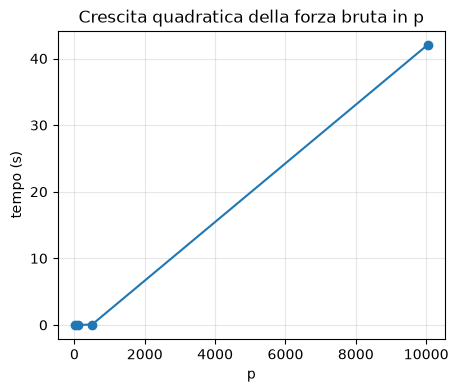

In [7]:
# Complexity

def primitive_roots_bruteforce(p):
    g_candidates = []
    for i in range(1, p):
        generated_elements = set()
        for exp in range(1, p):
            value = pow(i, exp, p)
            generated_elements.add(value)
            if len(generated_elements) == p - 1:
                break
        if len(generated_elements) == p - 1:
            g_candidates.append(i)
    return g_candidates

test_primes = [23, 101, 503, 10037]
times = []
for tp in test_primes:
    t0 = time.time()
    primitive_roots_bruteforce(tp)
    times.append(time.time() - t0)
    print(f"p={tp}: {times[-1]:.4f}s")

plt.figure(figsize=(5,4))
plt.plot(test_primes, times, marker='o')
plt.xlabel("p"); plt.ylabel("tempo (s)")
plt.title("Crescita quadratica della forza bruta in p")
plt.grid(True, alpha=0.3); plt.show()

#### We can do better

**Fatto chiave**: se $p$ è primo, il gruppo $\mathbb{Z}_p^*$ è ciclico di ordine $n = p - 1$. Per il
teorema di Lagrange, l'ordine di ogni elemento **divide** $n$. Quindi $g$ ha ordine *esattamente* $n$
(cioè è un generatore) **se e solo se** $g^{n/q} \neq 1 \pmod p$ per **ogni fattore primo** $q$ di $n$ —
non serve testare tutti gli esponenti fino a $n$, bastano tanti test quanti sono i fattori primi distinti
di $n$ (tipicamente una manciata, anche per $n$ enormi).


**Nota pratica importante**: il passo davvero "difficile" del metodo efficiente è **fattorizzare
$p-1$**. Per questo, quando si generano parametri di dominio per Diffie-Hellman in produzione, si
scelgono spesso **primi sicuri** (safe primes), cioè $p = 2q + 1$ con $q$ anch'esso primo: la
fattorizzazione di $p-1 = 2q$ è allora banale per costruzione (si conosce già $q$ generandolo), invece di
dover fattorizzare $p-1$ a posteriori con un algoritmo generico.

---

It is used in **cryptography to compute the modular inverse** of a number.  
Thanks to the **Extended Euclidean Algorithm** we can compute the GCD of two integer numbers and find two integers $x$ and $y$ such that:

$$
ax + by = \gcd(a,b)
$$

```text
FUNCTION ExtendedGCD(a, b):
    IF b = 0:
        RETURN (a, 1, 0)

    (gcd, x₁, y₁) ← ExtendedGCD(b, a mod b)

    x ← y₁
    y ← x₁ - ⌊a / b⌋ · y₁

    RETURN (gcd, x, y)

```



### Teorema di Fermat ed Eulero

# Computationally Hard Problems

DLP and IFP


## Discrete Logarithm Problem (DLP)

Given $(g, g^x)$ find $x$ 


Quanto costa un attacco dato che $p$ e' un numero di $n$ bit allora $2^{n-1} \leq p \leq 2^{n}$ 

$p \approx 2^n$ di conseguenza $∣G∣=p−1$ ovvero $G \approx 2^n$  

Per trovare $x$ dobbiamo provare tutti gli esponenti fino a trovare il valore giusto 

$$g^0, g^1, g^2, \cdots$$



Questo e' l'attacco brute force ma ci sta uno migliore che e' il big step small step 




, la funzione x → αˣ mod p si comporta come una permutazione pseudocasuale dell'insieme {1, ..., p−1} (assumendo α generatore, cioè che il suo ordine sia p−1). Non c'è una struttura "liscia" da invertire analiticamente: conoscendo β non hai un modo diretto per risalire a x, devi affidarti ad algoritmi generici (ricerca esaustiva, baby-step giant-step, Pollard's rho, o per campi finiti classici il metodo dell'index calculus).

In [8]:
"""
Visualizzazione del problema del logaritmo discreto (DLP).

Confronta la crescita "pura" di alpha^x con la sequenza alpha^x mod p,
per mostrare perché invertire la seconda (trovare x dato beta) e' difficile.

Include slider interattivi (ipywidgets) per cambiare alpha, p e x_max
a runtime in un notebook Jupyter, senza dover rieseguire la cella a mano.
"""

import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# -----------------------------------------------------------------------
# PARAMETRI (modifica questi per l'esercitazione)
# -----------------------------------------------------------------------
ALPHA = 2              # base / generatore
P = 8589935681         # modulo (deve essere primo per un vero gruppo DLP)
X_MAX = 600             # numero di esponenti da calcolare (x = 0 .. X_MAX-1)

# -----------------------------------------------------------------------
# CALCOLO DELLE SEQUENZE
# -----------------------------------------------------------------------
def compute_sequences(alpha, p, x_max):
    """Restituisce (x_values, beta_pure, beta_mod).

    beta_pure contiene alpha**x solo finche' resta <= p (oltre non serve
    disegnarlo, esplode subito fuori scala); beta_mod contiene alpha**x mod p
    per ogni x, calcolato in modo efficiente con pow(alpha, x, p).
    """
    x_values = list(range(x_max))

    beta_mod = [pow(alpha, x, p) for x in x_values]

    beta_pure_x, beta_pure_y = [], []
    value = 1
    for x in x_values:
        if value > p:
            break
        beta_pure_x.append(x)
        beta_pure_y.append(value)
        value *= alpha

    return x_values, (beta_pure_x, beta_pure_y), beta_mod


def plot_dlp(alpha, p, x_max):
    x_values, (pure_x, pure_y), mod_y = compute_sequences(alpha, p, x_max)

    fig, ax = plt.subplots(figsize=(5, 4))

    # Linea blu: crescita esponenziale pura (senza modulo)
    ax.plot(pure_x, pure_y, color="tab:blue", linewidth=1,
            label=r"$\beta = \alpha^{x}$")

    # Punti rossi: sequenza modulare (quella "difficile" da invertire)
    ax.scatter(x_values, mod_y, color="red", marker="*", s=25,
               label=r"$\beta = \alpha^{x}$ mod $p$")

    ax.set_yscale("log")
    ax.set_xlim(0, x_max)
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(rf"$\alpha$ = {alpha}, p = {p}")
    ax.grid(True, which="both", linestyle=":", linewidth=0.5)
    ax.legend(loc="lower right")

    fig.tight_layout()
    plt.show()  # in Jupyter mostra il grafico inline nella cella (con %matplotlib inline)


# -----------------------------------------------------------------------
# SLIDER INTERATTIVI (Jupyter)
# -----------------------------------------------------------------------
# Eseguendo questa cella in un notebook Jupyter compaiono 3 slider
# (alpha, p, x_max) e il grafico si ridisegna automaticamente ad ogni
# modifica. Nota: p viene forzato a un numero dispari per restare
# ragionevolmente vicino a un modulo "tipo primo" nei range piccoli;
# per un vero esercizio di crittografia scegli p effettivamente primo.
interact(
    plot_dlp,
    alpha=IntSlider(min=2, max=20, step=1, value=ALPHA, description="alpha"),
    p=IntSlider(min=11, max=200000, step=2, value=P if P < 200000 else 104729,
                description="p"),
    x_max=IntSlider(min=10, max=1000, step=10, value=X_MAX, description="x_max"),
)

interactive(children=(IntSlider(value=2, description='alpha', max=20, min=2), IntSlider(value=104729, descript…

<function __main__.plot_dlp(alpha, p, x_max)>

Come possiamo vedere fissando il valore di B abbiamo diversi valori di esponenti che ci danno lo stesso beta

## Integer Factorization Problem (IFP)